# Gradient Boosting Implementation

## Overview

In this notebook, I applied **Gradient Boosting** to predict Big Five personality traits (Extraversion, Agreeableness, Conscientiousness, Neuroticism, Openness) from textual life narrative responses (Q1–Q32).

### What is Gradient Boosting?

**Gradient Boosting** builds an ensemble of decision trees **sequentially** — each new tree corrects the errors of the previous ones. Unlike Random Forests (which builds trees in parallel), Gradient Boosting builds trees one at a time, each learning from the residual errors of the last.

We use **HistGradientBoostingRegressor**, scikit-learn's fast implementation inspired by LightGBM, which:
- Bins continuous features into histograms for speed
- Handles large feature sets efficiently
- Supports native missing value handling

### Why Gradient Boosting for personality prediction?
- Often outperforms Random Forests on structured/tabular data
- Combines well with TruncatedSVD-reduced TF-IDF features
- `learning_rate` + `max_iter` controls the bias-variance tradeoff carefully
- Strong baseline in NLP personality computing research

### Pipeline
```
Narrative text (Q columns)
        ↓
TF-IDF Vectorization (up to 200k features, bigrams)
        ↓
TruncatedSVD → 300 dense dimensions
        ↓
HistGradientBoostingRegressor (one per trait)
        ↓
5-Fold Cross-Validation + Evaluation
```

## 1. Data preprocessing, import required packages

As specified in the random forest module, all narrative columns are combined into a single text string per participant, then apply **TF-IDF** (Term Frequency–Inverse Document Frequency) to convert text into a numeric matrix. 

The key process of supervised learning is for model to learn patterns from training set and evaluate model performance on unseen test set. Thus, data is split into **80% training** and **20% testing**.`random_state=42` ensures reproducibility

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("✓ Imports complete")

# Find repo root automatically
repo_root = Path.cwd().resolve()
while not (repo_root / "BFI_2_life_narative_metadata.json").exists():
    if repo_root == repo_root.parent:
        raise FileNotFoundError("Could not find BFI_2_life_narative_metadata.json")
    repo_root = repo_root.parent

# Load data
with open(repo_root / "BFI_2_life_narative_metadata.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

with open(repo_root / "BFI_2_life_narrative.json", "r", encoding="utf-8") as f:
    responses = json.load(f)

df = pd.DataFrame(responses)

# Reverse-code BFI items
reverse_items = metadata["reverse_code_items"]

for item in reverse_items:
    if item in df.columns:
        df[item] = 6 - df[item]

# Big Five trait means
traits = {
    key: value
    for key, value in metadata.items()
    if (
        isinstance(value, list)
        and value
        and isinstance(value[0], str)
        and value[0].startswith("Item")
        and not key.startswith(("Item", "Q", "CWB", "OCB"))
        and key != "reverse_code_items"
    )
}

for trait, items in traits.items():
    available_items = [item for item in items if item in df.columns]
    df[trait] = df[available_items].mean(axis=1)

# CWB and OCB means
cwb_cols = [f"CWB{i}" for i in range(1, 11) if f"CWB{i}" in df.columns]
ocb_cols = [f"OCB{i}" for i in range(1, 11) if f"OCB{i}" in df.columns]

df["CWB"] = df[cwb_cols].mean(axis=1)
df["OCB"] = df[ocb_cols].mean(axis=1)

# Text features
q_cols = [c for c in df.columns if isinstance(c, str) and c.startswith("Q")]

X_text = df[q_cols].copy()
X_all = X_text.fillna("").agg(" ".join, axis=1)

# Targets
big_five = [
    "Extraversion",
    "Agreeableness",
    "Conscientiousness",
    "Neuroticism",
    "Openness",
]

y = df[big_five].copy()

print("✓ Data preprocessing complete")
print("Repo root:", repo_root)
print("df shape:", df.shape)
print("X_text shape:", X_text.shape)
print("X_all shape:", X_all.shape)
print(y.describe().round(3))

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

✓ Imports complete
✓ Data preprocessing complete
Repo root: /Users/cindy/cmor438_Spring2026/cmor438_Spring2026
df shape: (500, 138)
X_text shape: (500, 32)
X_all shape: (500,)
       Extraversion  Agreeableness  Conscientiousness  Neuroticism  Openness
count       500.000        500.000            500.000      500.000   500.000
mean          3.177          3.786              3.642        2.879     3.833
std           0.761          0.576              0.710        0.846     0.618
min           1.000          2.000              1.083        1.000     1.750
25%           2.667          3.417              3.167        2.333     3.417
50%           3.167          3.833              3.750        2.917     3.833
75%           3.750          4.167              4.083        3.417     4.250
max           5.000          5.000              5.000        4.917     5.000
Training samples : 400
Test samples     : 100


## 

In [2]:
def cross_validate_model(model, X, y, trait_cols, n_splits=5):
    """
    Run k-fold cross-validation and return per-fold and summary metrics.

    Parameters
    ----------
    model      : sklearn-compatible pipeline
    X          : Series of narrative strings
    y          : DataFrame of trait scores
    trait_cols : list of trait column names
    n_splits   : number of CV folds (default: 5)

    Returns
    -------
    fold_results : DataFrame with per-fold metrics
    summary      : DataFrame with mean metrics per trait
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)

        for j, trait in enumerate(trait_cols):
            y_true = y_te[trait].to_numpy()
            y_pred = pred[:, j]
            fold_results.append({
                "Fold":      fold + 1,
                "Trait":     trait,
                "MAE":       mean_absolute_error(y_true, y_pred),
                "R2":        r2_score(y_true, y_pred),
                "Pearson_r": np.corrcoef(y_true, y_pred)[0, 1]
            })

    results_df = pd.DataFrame(fold_results)
    summary    = results_df.groupby("Trait").mean(numeric_only=True).round(4)
    return results_df, summary


def plot_cv_summary(summary, title):
    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(summary.index, summary["R2"], color=colors)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylabel("Mean CV R²")
    ax.set_title(title)
    for bar, val in zip(bars, summary["R2"]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()


print("✓ Helper functions defined")

✓ Helper functions defined


In [ ]:
## 5. Build and Train the Gradient Boosting Model

### Key hyperparameters
| Parameter | Value | Why |
|---|---|---|
| `learning_rate` | 0.05 | Small steps = more robust generalization |
| `max_depth` | 6 | Moderate tree depth, controls complexity |
| `max_iter` | 400 | More trees to compensate for small learning rate |
| `n_components` (SVD) | 300 | Captures ~80% of TF-IDF variance |

In [3]:
gb_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=3,
        max_features=200_000
    )),
    # Reduce sparse TF-IDF to 300 dense dimensions
    ("svd",  TruncatedSVD(n_components=300, random_state=42)),
    ("reg",  MultiOutputRegressor(
        HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_depth=6,
            max_iter=400,
            random_state=42
        )
    ))
])

gb_model.fit(X_train, y_train)
pred_gb = gb_model.predict(X_test)

mae_gb = mean_absolute_error(y_test, pred_gb, multioutput="raw_values")
r2_gb  = [r2_score(y_test.iloc[:, i], pred_gb[:, i]) for i in range(y.shape[1])]

print("Gradient Boosting — Test Set Performance")
print("MAE by trait:", dict(zip(big_five, mae_gb.round(4))))
print("R²  by trait:", dict(zip(big_five, [round(r, 4) for r in r2_gb])))

Gradient Boosting — Test Set Performance
MAE by trait: {'Extraversion': np.float64(0.6358), 'Agreeableness': np.float64(0.4503), 'Conscientiousness': np.float64(0.5939), 'Neuroticism': np.float64(0.7236), 'Openness': np.float64(0.5838)}
R²  by trait: {'Extraversion': -0.0489, 'Agreeableness': -0.3621, 'Conscientiousness': 0.0225, 'Neuroticism': 0.0652, 'Openness': -0.2083}


Gradient Boosting — 5-Fold Cross-Validation
---------------------------------------------
                      MAE      R2  Pearson_r
Trait                                       
Agreeableness      0.4860 -0.2133     0.0197
Conscientiousness  0.5515  0.0206     0.2730
Extraversion       0.6035 -0.0052     0.1857
Neuroticism        0.6615  0.0383     0.2551
Openness           0.5112 -0.1231     0.1591


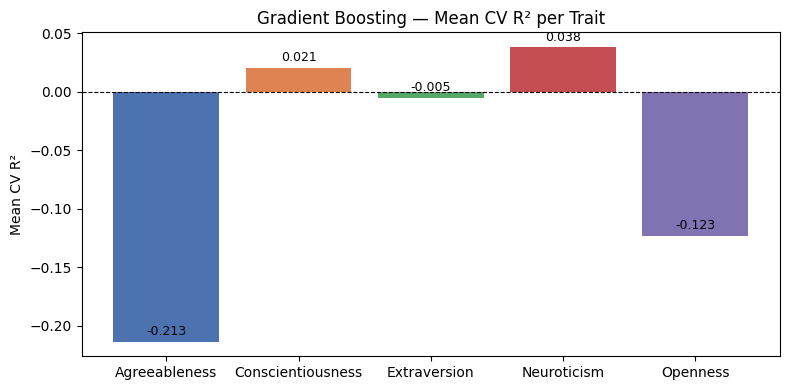

In [4]:
print("Gradient Boosting — 5-Fold Cross-Validation")
print("-" * 45)

_, summary_gb = cross_validate_model(gb_model, X_all, y, big_five, n_splits=5)

print(summary_gb[["MAE", "R2", "Pearson_r"]])
plot_cv_summary(summary_gb, "Gradient Boosting — Mean CV R² per Trait")

## Results analysis

#### Pearson Correlation Comparison Across Tree-Based Models

| Trait | Decision Tree | Random Forest | Gradient Boosting |
|---|---:|---:|---|
| Agreeableness | -0.0138 | **0.0296** | 0.0197 |
| Conscientiousness | 0.2035 | **0.2916** | 0.2730 | 
| Extraversion | -0.0036 | **0.2981** | 0.1857 | 
| Neuroticism | 0.1248 | **0.2601** | 0.2551 | 
| Openness | 0.0436 | 0.1396 | **0.1591** |


### Comparison of Tree-Based Regression Models

Among the three tree-based approaches, **Random Forest** achieved the strongest overall predictive performance based on Pearson’s *r*, producing the highest correlations for four of the five personality traits, suggesting that averaging predictions across many trees improved generalization and reduced overfitting relative to a single decision tree.

**Decision Tree** showed the weakest performance overall, with near-zero or negative correlations for several traits. This suggests that a single tree may have been too unstable or overly simplistic to capture the complex relationships between predictors and personality outcomes.

**Gradient Boosting** performed better than a single decision tree and was competitive with Random Forest on some traits, particularly **Neuroticism** (*r* = 0.2551) and **Conscientiousness** (*r* = 0.2730). It also achieved the best result for **Openness**. However, it did not consistently outperform Random Forest, which may indicate that additional hyperparameter tuning would be needed to fully optimize boosting performance.

Overall, results suggest that **ensemble methods outperform a single tree model**, with **Random Forest providing the most consistent predictive accuracy**, although effect sizes remained modest across all models.